## ¿Es la educación superior un catalizador para la denuncia de violencia no física?
    Se asume que en los departamentos con mayor porcentaje de población con educación superior, la proporción de denuncias por violencia psicológica será significativamente mayor que la de violencia física. La creencia es que a mayor nivel educativo, existe una mayor "alfabetización en derechos" y una menor tolerancia al maltrato emocional, mientras que en zonas de baja escolaridad solo se denunciaría cuando hay daño corporal visible. 

--- Iniciando Análisis: Educación Superior vs Tipo de Violencia (2018) ---
Departamentos analizados: 22

Top 5 Deptos con mayor Educación Superior:
      departamento  prop_superior  prop_psicologica
6        Guatemala      12.215548         66.616677
12  Quetzaltenango      11.881214         57.662123
15    Sacatepéquez       7.167720         61.120000
21          Zacapa       3.887489         64.685714
4      El Progreso       3.799648         66.852368

Correlación Spearman: 0.3529 (p=1.0718e-01)


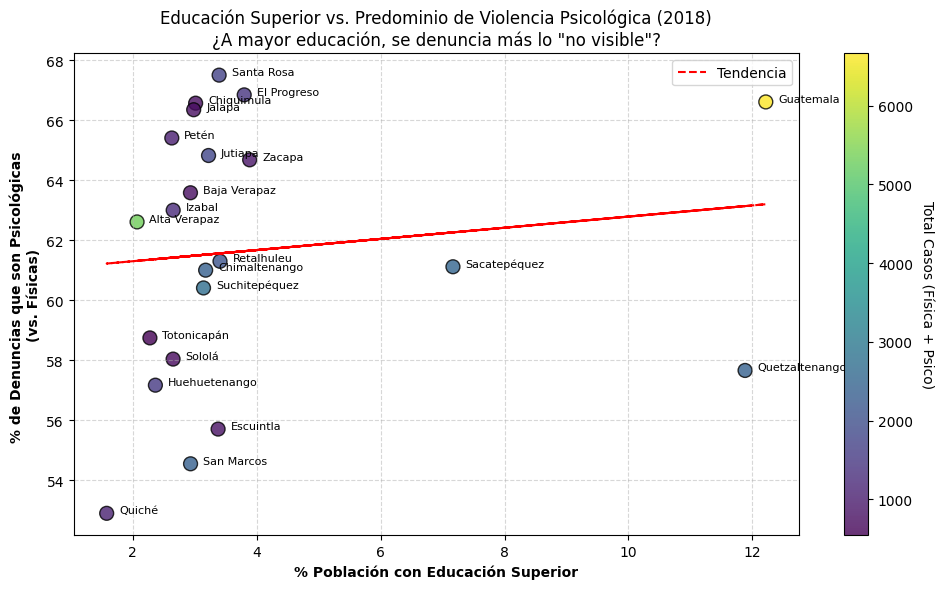

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
# --- CONFIGURACIÓN ---
project_root = Path.cwd()
while not (project_root / 'data_pipeline.py').exists():
    if project_root.parent == project_root: raise FileNotFoundError("No data_pipeline.py found")
    project_root = project_root.parent
if str(project_root) not in sys.path: sys.path.append(str(project_root))
import data_pipeline as dp
print("--- Iniciando Análisis: Educación Superior vs Tipo de Violencia (2018) ---")
try:
    # 1. Cargar Datos VIF (2018)
    df_panel = dp.build_panel(force_rebuild=False, only_common_years=False)
    df_vif = df_panel[df_panel['anio'] == 2018].copy()
    
    # Identificar columnas por tipo de violencia
    cols_psico = [c for c in df_vif.columns if 'psicologic' in c.lower() or 'verb' in c.lower()]
    cols_fisica = [c for c in df_vif.columns if 'fisic' in c.lower()]
    
    if not cols_psico or not cols_fisica:
        # Intento de fallback si los nombres no coinciden (ajustar según tus columnas reales)
        # Asumiendo que tu pipeline genera algo como 'vif_tipo_fisica', 'vif_tipo_psicologica'
        print(f"Columnas disponibles: {[c for c in df_vif.columns if 'vif_tipo' in c]}")
        raise KeyError("No se pudieron identificar automáticamente las columnas de violencia física/psicológica.")
    # Calcular totales por tipo
    df_vif['total_psicologica'] = df_vif[cols_psico].sum(axis=1)
    df_vif['total_fisica'] = df_vif[cols_fisica].sum(axis=1)
    
    # Calcular % de violencia que es PSICOLÓGICA (sobre el total de física+psicológica)
    # Ignoramos otros tipos (económica, sexual) para este contraste específico
    df_vif['prop_psicologica'] = df_vif['total_psicologica'] / (df_vif['total_psicologica'] + df_vif['total_fisica']) * 100
    # 2. Cargar Datos Educación (2018)
    edu_path = project_root / 'Datos/Poblacion/nivel_educativo.csv'
    df_edu = pd.read_csv(edu_path)
    
    # Estandarizar departamentos
    df_edu.rename(columns={'Departamento': 'departamento', 'Código': 'codigo_depto'}, inplace=True)
    df_edu['departamento'] = df_edu['departamento'].apply(dp._standardize_department)
    
    # Calcular % con Educación Superior 
    # (Licenciatura + Maestría/Doc) / Población de 4 años o más
    df_edu['pob_superior'] = df_edu['Superior_Licenciatura'] + df_edu['Superior_Maestria_Doc']
    df_edu['prop_superior'] = (df_edu['pob_superior'] / df_edu['Poblacion_4_mas']) * 100
    # 3. Unir Datos
    df_final = pd.merge(df_vif[['departamento', 'prop_psicologica', 'total_psicologica', 'total_fisica']],
                        df_edu[['departamento', 'prop_superior']],
                        on='departamento', how='inner')
    
    # Limpieza final
    df_analisis = df_final.dropna().copy()
    
    print(f"Departamentos analizados: {len(df_analisis)}")
    print("\nTop 5 Deptos con mayor Educación Superior:")
    print(df_analisis.sort_values('prop_superior', ascending=False).head(5)[['departamento', 'prop_superior', 'prop_psicologica']])
    # 4. Análisis Estadístico
    coef, p_value = spearmanr(df_analisis['prop_superior'], df_analisis['prop_psicologica'])
    print(f"\nCorrelación Spearman: {coef:.4f} (p={p_value:.4e})")
    
    # 5. Visualización
    plt.figure(figsize=(10, 6))
    
    # Scatterplot
    scatter = plt.scatter(df_analisis['prop_superior'], df_analisis['prop_psicologica'], 
                          c=df_analisis['total_psicologica'] + df_analisis['total_fisica'], 
                          cmap='viridis', s=100, alpha=0.8, edgecolors='k')
    
    # Línea de tendencia
    z = np.polyfit(df_analisis['prop_superior'], df_analisis['prop_psicologica'], 1)
    p = np.poly1d(z)
    plt.plot(df_analisis['prop_superior'], p(df_analisis['prop_superior']), "r--", label='Tendencia')
    # Etiquetas
    for i, row in df_analisis.iterrows():
        plt.text(row['prop_superior']+0.2, row['prop_psicologica'], row['departamento'], fontsize=8)
    cbar = plt.colorbar(scatter)
    cbar.set_label('Total Casos (Física + Psico)', rotation=270, labelpad=15)
    plt.title(f'Educación Superior vs. Predominio de Violencia Psicológica (2018)\n¿A mayor educación, se denuncia más lo "no visible"?', fontsize=12)
    plt.xlabel('% Población con Educación Superior', fontweight='bold')
    plt.ylabel('% de Denuncias que son Psicológicas \n(vs. Físicas)', fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error: {e}")